<a href="https://colab.research.google.com/github/moulisha10/image_recognition/blob/main/image_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"moulisharoy","key":"9d766d94505ca3ad9f1bf73c821e2c37"}'}

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mnist-dataset' dataset.
Path to dataset files: /kaggle/input/mnist-dataset


In [ ]:
import tensorflow as tf
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (60000, 28, 28), Test shape: (10000, 28, 28)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0
x_train = X_train.reshape(-1,28,28,1)
x_test = X_test.reshape(-1,28,28,1)
print(f"Train shape: {X_train.shape}")

Train shape: (60000, 28, 28)


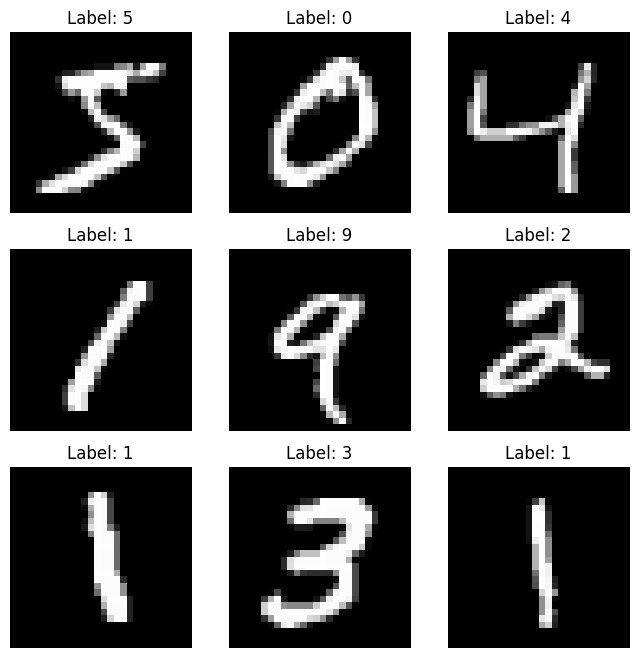

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(x_train[i].reshape(28,28), cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.show()

In [ ]:
(X_train_c10, y_train_c10), (X_test_c10, y_test_c10) = tf.keras.datasets.cifar10.load_data()
X_train_c10 = X_train_c10 / 255.0
X_test_c10 = X_test_c10 / 255.0
print(f"CIFAR-10 train shape {X_train_c10.shape}")

CIFAR-10 train shape (50000, 32, 32, 3)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
model = Sequential ([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.8980 - loss: 0.3317 - val_accuracy: 0.9852 - val_loss: 0.0510
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.9841 - loss: 0.0523 - val_accuracy: 0.9862 - val_loss: 0.0444
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9900 - loss: 0.0330 - val_accuracy: 0.9852 - val_loss: 0.0469
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9933 - loss: 0.0218 - val_accuracy: 0.9894 - val_loss: 0.0399
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9956 - loss: 0.0151 - val_accuracy: 0.9905 - val_loss: 0.0346


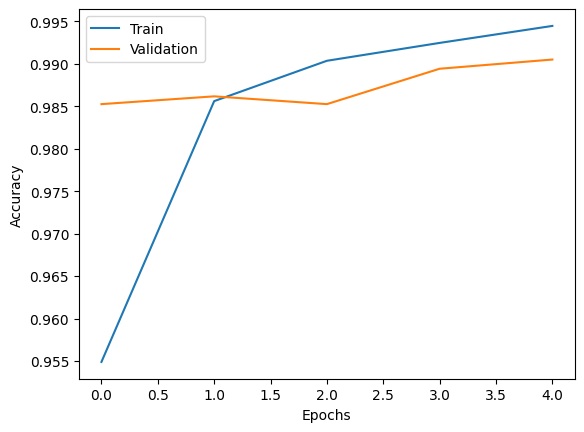

In [ ]:
 plt.plot(history.history['accuracy'], label='Train')
 plt.plot(history.history['val_accuracy'], label='Validation')
 plt.xlabel('Epochs')
 plt.ylabel('Accuracy')
 plt.legend()
 plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy: {test_acc:.4f}")
y_pred = model.predict(X_test).argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9869 - loss: 0.0359
Test accuracy: {test_acc:.4f}
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [ ]:
from tensorflow.keras.layers import Dropout
model = Sequential ([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Dropout(0.25),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train_c10)

In [ ]:
from tensorflow.keras.layers import BatchNormalization
model = Sequential ([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(datagen.flow(X_train_c10, y_train_c10, batch_size=32), epochs=10, validation_data=(X_test_c10, y_test_c10))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 85ms/step - accuracy: 0.3482 - loss: 1.7896 - val_accuracy: 0.5544 - val_loss: 1.2370
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 129s 82ms/step - accuracy: 0.5096 - loss: 1.3801 - val_accuracy: 0.6124 - val_loss: 1.0878
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 85ms/step - accuracy: 0.5472 - loss: 1.2798 - val_accuracy: 0.5730 - val_loss: 1.2908
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 128s 82ms/step - accuracy: 0.5778 - loss: 1.1992 - val_accuracy: 0.6381 - val_loss: 1.0534
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.5971 - loss: 1.1593 - val_accuracy: 0.6169 - val_loss: 1.1243
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.6051 - loss: 1.1266 - val_accuracy: 0.6525 - val_loss: 1.0020
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.6203 - loss: 1.0952 - val_accuracy: 0.6450 - val_loss: 1.0069
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 89ms/step - accuracy: 0.6261 - lo

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.00      0.00      0.00      1000
           2       0.00      0.00      0.00      1000
           3       0.10      0.69      0.17      1000
           4       0.20      0.00      0.01      1000
           5       0.09      0.00      0.01      1000
           6       0.11      0.00      0.00      1000
           7       0.00      0.00      0.00      1000
           8       0.00      0.00      0.00      1000
           9       0.14      0.40      0.20      1000

    accuracy                           0.11     10000
   macro avg       0.06      0.11      0.04     10000
weighted avg       0.06      0.11      0.04     10000



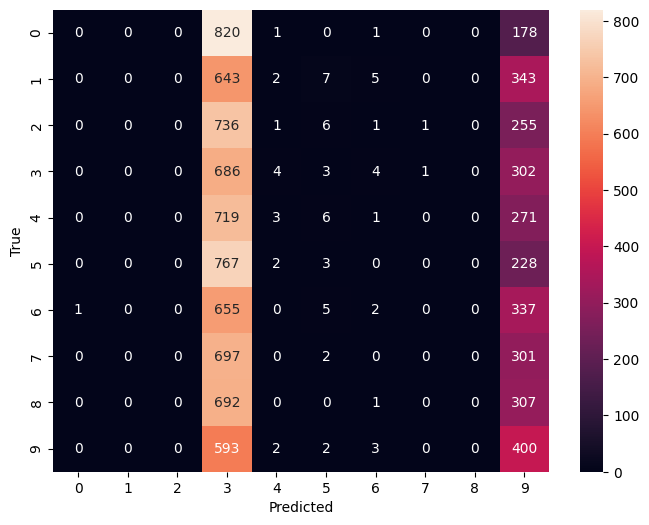

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Redefine and compile the CIFAR-10 model (from cell emhfjesRe716) if it wasn't executed
# Note: This model will be untrained if cell emhfjesRe716 was skipped
model = Sequential ([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

y_pred_10 = model.predict(X_test_c10).argmax(axis=1)
cm= confusion_matrix(y_test_c10, y_pred_10)
print(classification_report(y_test_c10, y_pred_10))

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
 53% 115M/218M [00:00<00:00, 1.20GB/s]
100% 218M/218M [00:00<00:00, 412MB/s] 


In [ ]:
import zipfile
with zipfile.ZipFile('/content/cat-and-dog.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dogs-vs-cats')

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen= ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_generator= datagen.flow_from_directory(
    '/content/dogs-vs-cats/training_set/training_set',
    target_size=(224,224),
    batch_size=32, class_mode='binary', subset='training'
)
val_generator= datagen.flow_from_directory(
    '/content/dogs-vs-cats/training_set/training_set',
    target_size=(224,224),
    batch_size=32, class_mode='binary', subset='validation')

Found 6404 images belonging to 2 classes.
Found 1601 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
base_model= MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable= False
model= Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'), Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_generator, epochs = 5, validation_data = val_generator)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 341s 2s/step - accuracy: 0.9411 - loss: 0.1352 - val_accuracy: 0.9856 - val_loss: 0.0474
Epoch 2/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.9844 - loss: 0.0371 - val_accuracy: 0.9800 - val_loss: 0.0563
Epoch 3/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.9884 - loss: 0.0293 - val_accuracy: 0.9819 - val_loss: 0.0513
Epoch 4/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.9912 - loss: 0.0193 - val_accuracy: 0.9794 - val_loss: 0.0537
Epoch 5/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.9953 - loss: 0.0132 - val_accuracy: 0.9856 - val_loss: 0.0515


In [ ]:
base.model.trainable= True
model.compile(optimizer= tf.keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_generator, epochs=5, validation_data=val_generator)

In [ ]:
model.save('moblienet_cats_dogs.h5')
import tensorflow as tf
loaded_model= tf.keras.models.load_model('moblienet_cats_dogs.h5')

In [ ]:
from sklearn.metrics import roc_curve, auc
y_pred_proba = loaded_model.predict(val_generator)
fpr, tpr, _ = roc_curve(val_generator.classes, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
!ls -R /content/dogs-vs-cats

/content/dogs-vs-cats:
test_set  training_set

/content/dogs-vs-cats/test_set:
test_set

/content/dogs-vs-cats/test_set/test_set:
cats  dogs

/content/dogs-vs-cats/test_set/test_set/cats:
 cat.4001.jpg	    cat.4249.jpg       cat.4501.jpg	  cat.4751.jpg
 cat.4002.jpg	    cat.4250.jpg       cat.4502.jpg	  cat.4752.jpg
 cat.4003.jpg	    cat.4251.jpg       cat.4503.jpg	  cat.4753.jpg
 cat.4004.jpg	    cat.4252.jpg       cat.4504.jpg	  cat.4754.jpg
 cat.4005.jpg	    cat.4253.jpg       cat.4505.jpg	  cat.4755.jpg
 cat.4006.jpg	    cat.4254.jpg       cat.4506.jpg	  cat.4756.jpg
 cat.4007.jpg	    cat.4255.jpg       cat.4507.jpg	  cat.4757.jpg
 cat.4008.jpg	    cat.4256.jpg       cat.4508.jpg	  cat.4758.jpg
 cat.4009.jpg	    cat.4257.jpg       cat.4509.jpg	  cat.4759.jpg
 cat.4010.jpg	    cat.4258.jpg       cat.4510.jpg	  cat.4760.jpg
 cat.4011.jpg	    cat.4259.jpg       cat.4511.jpg	  cat.4761.jpg
 cat.4012.jpg	    cat.4260.jpg       cat.4512.jpg	  cat.4762.jpg
 cat.4013.jpg	    cat.4261.jpg  

In [ ]:
from google.colab import files
uploaded = files.upload()

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

img_path = '/content/golden-retriever-tongue-out.jpg'
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = loaded_model.predict(img_array)
print("Predicted class:", "Dog" if prediction[0][0] > 0.5 else "Cat")

KeyboardInterrupt: 